<a href="https://colab.research.google.com/github/georgsturlajs-ctrl/fita-ml-course/blob/main/week1_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. nedēļas mājasdarbs: Datu sagatavošana

1. Uzdevums: Biznesa konteksts un ML mērķis

1.1. Problēmas apraksts

Mēs analizējam tiešsaistes mazumtirgotāja e-komercijas datus (Online Shopper Intentions), lai saprastu apmeklētāju uzvedību.
Mērķis: Izstrādāt modeli, kas prognozē, vai lietotāja sesija beigsies ar pirkumu (Revenue = True).
Biznesa vērtība: Uzņēmums var precīzāk mērķēt reklāmas un piedāvāt personalizētas atlaides reāllaikā tiem lietotājiem, kuriem ir augsts pirkuma potenciāls.

1.2. ML tipa identificēšana

Tips: Supervised Learning (Uzraudzītā mācīšanās), jo mums ir pieejami vēsturiskie dati ar zināmu iznākumu (Revenue).

Apakštips: Classification (Klasifikācija), jo mēs iedalām sesijas divās diskrētās grupās: Pirkums / Nav pirkuma.

1.3. Target un Features

Target mainīgais: Revenue

Features (Pazīmes): * Skaitliskās: Administrative_Duration, ProductRelated_Duration, ExitRates, PageValues.

Kategoriskās: Month, VisitorType, Weekend.

In [4]:
# 2.1. Bibliotēku imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Vizuālie iestatījumi grafikiem
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Visas bibliotēkas ielādētas veiksmīgi")

# 2.2. Datu ielāde
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"✓ Dati ielādēti. Kopā ir {df.shape[0]} rindas un {df.shape[1]} kolonnas.")

# 2.3. Sākotnējā datu apskate
# Parādām pirmās 5 rindas, lai pārliecinātos, ka viss izskatās pareizi
display(df.head())

# Pārbaudām datu tipus un trūkstošās vērtības
print("\nInformācija par datu tipiem:")
df.info()

print("\nTrūkstošo vērtību skaits katrā kolonnā:")
print(df.isnull().sum())

✓ Visas bibliotēkas ielādētas veiksmīgi
✓ Dati ielādēti. Kopā ir 12330 rindas un 18 kolonnas.


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Informācija par datu tipiem:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Iestatījumi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Visas bibliotēkas ielādētas veiksmīgi")


✓ Visas bibliotēkas ielādētas veiksmīgi


In [7]:
# Ielādē datu kopu tieši no UCI repozitorija
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Datu kopu forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
print("\nPirmās 5 rindas:")
print(df.head())


Datu kopu forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0

In [8]:
# Datu tipi
print("Datu tipi:")
print(df.dtypes)


Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [9]:
# Statistika par skaitliskajām kolonnām
print("Skaitlisko kolonnu statistika:")
print(df.describe())


Skaitlisko kolonnu statistika:
       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%          

In [10]:
# Trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())


Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [11]:
# Kategoriskās kolonnas
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Kategoriskās kolonnas: {cat_cols}")


Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']


In [12]:
# Target mainīgā sadalījums
print("Target mainīgā (Revenue) sadalījums:")
print(df['Revenue'].value_counts())
print(f"Pirkumu īpatsvars: {df['Revenue'].sum() / len(df) * 100:.2f}%")


Target mainīgā (Revenue) sadalījums:
Revenue
False    10422
True      1908
Name: count, dtype: int64
Pirkumu īpatsvars: 15.47%


In [13]:
# Kuras kolonnas satur trūkstošas vērtības?
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Kolonnas ar trūkstošām vērtībām:")
print(missing)

# Vizualizācija
if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='barh', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.xlabel('Trūkstošo vērtību skaits')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Trūkstošo vērtību nav — dati ir tīri!")


Kolonnas ar trūkstošām vērtībām:
Series([], dtype: int64)
✓ Trūkstošo vērtību nav — dati ir tīri!


In [14]:
# Skaitliskām kolonnām — mediāna
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✓ {col}: aizpildīts ar mediānu {median_val:.2f}")

# Kategoriskām kolonnām — moda
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✓ {col}: aizpildīts ar modu '{mode_val}'")

# Galīgā pārbaude
assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"
print("\n✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() =", df.isnull().sum().sum())



✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() = 0


In [15]:
# Kādas ir kategoriskās kolonnas?
print("Kategoriskās kolonnas:")
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unikālas vērtības")
    print(df[col].unique()[:10])  # Parāda pirmos 10


Kategoriskās kolonnas:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: 10 unikālas vērtības
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unikālas vērtības
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unikālas vērtības
[False  True]

Revenue: 2 unikālas vērtības
[False  True]


In [16]:
# Boolean/binary kolonnas — Label Encoding
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print("✓ Boolean kolonnas konvertētas uz 0/1")


✓ Boolean kolonnas konvertētas uz 0/1


In [17]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
print(f"✓ One-Hot Encoding pabeigts. Jaunas kolonnas: {df.shape[1]}")
print("Nākamās jaunās kolonnas:")
print(df.columns[df.columns.str.contains('Month|VisitorType')])


✓ One-Hot Encoding pabeigts. Jaunas kolonnas: 27
Nākamās jaunās kolonnas:
Index(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')


In [2]:
# Pārliecinies, ka nav palikušas neapstrādātas kategoriskās kolonnas
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Explicitly convert the identified one-hot encoded columns to integer type
# This addresses cases where select_dtypes might still classify them as 'object' or 'bool'
for col in remaining_cat:
    if df[col].dtype == 'object' or df[col].dtype == 'bool':
        df[col] = df[col].astype(int)
        print(f"Pārveidota kolonna '{col}' uz int datus tipu.")

# Re-evaluate remaining categorical columns after explicit conversion
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()

assert len(remaining_cat) == 0, f"Vēl neapstrādātas kategoriskās kolonnas: {remaining_cat}"
print("✓ Visas kategoriskās kolonnas kodētas. Atlikt: ", len(remaining_cat))

NameError: name 'df' is not defined

In [18]:
# Pārliecinies, ka nav palikušas neapstrādātas kategoriskās kolonnas
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Explicitly convert the identified one-hot encoded columns to integer type
# This addresses cases where select_dtypes might still classify them as 'object' or 'bool'
for col in remaining_cat:
    if df[col].dtype == 'object' or df[col].dtype == 'bool':
        df[col] = df[col].astype(int)
        print(f"Pārveidota kolonna '{col}' uz int datus tipu.")

# Re-evaluate remaining categorical columns after explicit conversion
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()

assert len(remaining_cat) == 0, f"Vēl neapstrādātas kategoriskās kolonnas: {remaining_cat}"
print("✓ Visas kategoriskās kolonnas kodētas. Atlikt: ", len(remaining_cat))

# Visas kolonnas tagad ir skaitliskas
print(f"\nKolonnu skaits pēc kodēšanas: {df.shape[1]}")
print("Dati tipi:")
print(df.dtypes.value_counts())

Pārveidota kolonna 'Month_Dec' uz int datus tipu.
Pārveidota kolonna 'Month_Feb' uz int datus tipu.
Pārveidota kolonna 'Month_Jul' uz int datus tipu.
Pārveidota kolonna 'Month_June' uz int datus tipu.
Pārveidota kolonna 'Month_Mar' uz int datus tipu.
Pārveidota kolonna 'Month_May' uz int datus tipu.
Pārveidota kolonna 'Month_Nov' uz int datus tipu.
Pārveidota kolonna 'Month_Oct' uz int datus tipu.
Pārveidota kolonna 'Month_Sep' uz int datus tipu.
Pārveidota kolonna 'VisitorType_Other' uz int datus tipu.
Pārveidota kolonna 'VisitorType_Returning_Visitor' uz int datus tipu.
✓ Visas kategoriskās kolonnas kodētas. Atlikt:  0

Kolonnu skaits pēc kodēšanas: 27
Dati tipi:
int64      20
float64     7
Name: count, dtype: int64


In [19]:
# Kādas ir skaitliskās kolonnas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Skaitliskās kolonnas ({len(numeric_cols)} pavisam):")
print(numeric_cols[:30])  # Parāda pirmos 30

# Statistika PIRMS normalizācijas
print("\n=== STATISTIKA PIRMS NORMALIZĀCIJAS ===")
print(df[numeric_cols[:6]].describe().round(2))


Skaitliskās kolonnas (27 pavisam):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Revenue', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']

=== STATISTIKA PIRMS NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.82           0.50   
std              3.32                   176.78           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.50           0.00   
75%              4.00        

In [20]:
from sklearn.preprocessing import StandardScaler

# Atlasi skaļošanai VISAS skaitliskās kolonnas (izņemot target)
cols_to_scale = [col for col in numeric_cols if col != 'Revenue']

# StandardScaler: (x - mean) / std
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"✓ {len(cols_to_scale)} skaitliskās kolonnas normalizētas")
print("\n=== STATISTIKA PĒC NORMALIZĀCIJAS ===")
print(df[cols_to_scale[:6]].describe().round(2))


✓ 26 skaitliskās kolonnas normalizētas

=== STATISTIKA PĒC NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00        12330.0   
mean            -0.00                     0.00           -0.0   
std              1.00                     1.00            1.0   
min             -0.70                    -0.46           -0.4   
25%             -0.70                    -0.46           -0.4   
50%             -0.40                    -0.41           -0.4   
75%              0.51                     0.07           -0.4   
max              7.43                    18.77           18.5   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
mean                    -0.00            0.00                    -0.00  
std                      1.00            1.00                     1.00  
min                     -0.24           -0.7

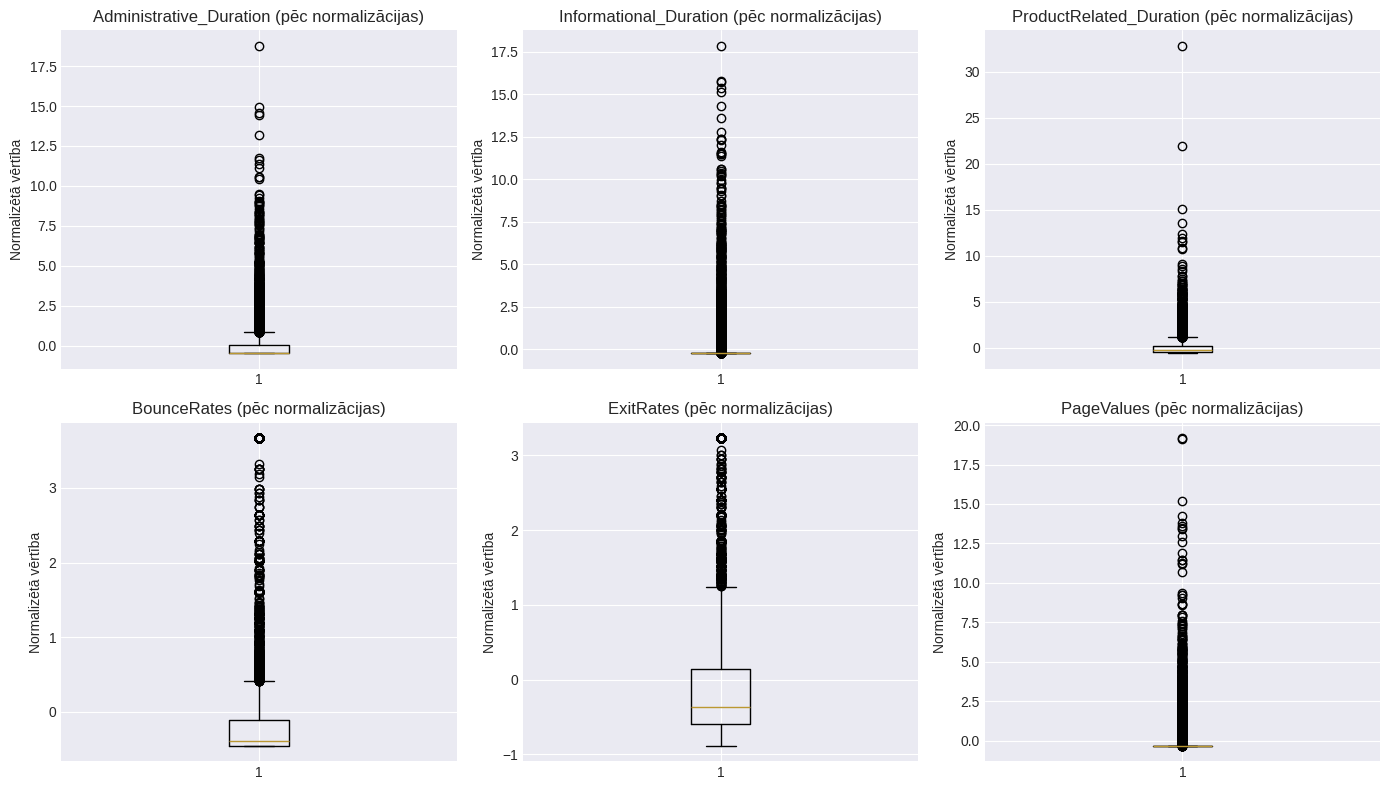

✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1


In [21]:
# Salīdzinājums:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sample_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
               'BounceRates', 'ExitRates', 'PageValues']

for idx, col in enumerate(sample_cols):
    if col in df.columns:
        axes[idx].boxplot(df[col], vert=True)
        axes[idx].set_title(f'{col} (pēc normalizācijas)')
        axes[idx].set_ylabel('Normalizētā vērtība')

plt.tight_layout()
plt.show()

print("✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1")


In [22]:
# Aprēķinām kopējo laikā, ko lietotājs pavadījis visās lapās kopā
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# Aprēķinām vidējo laiku vienā lapā (tikai lai parādītu, cik dažādas var būt idejas)
# Pievienojam +1, lai izvairītos no dalīšanas ar nulli
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Administrative'] + df['Informational'] + df['ProductRelated'] + 1)

print("✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'")
print(f"Datu kopas forma tagad: {df.shape}") # Jābūt par 2 kolonnām vairāk

# Apskatām jauno kolonnu pirmās rindas
display(df[['Total_Duration', 'Avg_Time_Per_Page']].head())

✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'
Datu kopas forma tagad: (12330, 29)


,Total_Duration,Avg_Time_Per_Page
0,-1.326469,1.690903
1,-1.293024,1.696907
2,-1.326469,1.690903
3,-1.325076,1.738970
4,-0.998552,1.715409


In [23]:
# Aprēķinām kopējo laikā, ko lietotājs pavadījis visās lapās kopā
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# Aprēķinām vidējo laiku vienā lapā (tikai lai parādītu, cik dažādas var būt idejas)
# Pievienojam +1, lai izvairītos no dalīšanas ar nulli
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Administrative'] + df['Informational'] + df['ProductRelated'] + 1)

print("✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'")
print(f"Datu kopas forma tagad: {df.shape}") # Jābūt par 2 kolonnām vairāk

# Apskatām jauno kolonnu pirmās rindas
display(df[['Total_Duration', 'Avg_Time_Per_Page']].head())

✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'
Datu kopas forma tagad: (12330, 29)


,Total_Duration,Avg_Time_Per_Page
0,-1.326469,1.690903
1,-1.293024,1.696907
2,-1.326469,1.690903
3,-1.325076,1.738970
4,-0.998552,1.715409


In [24]:
# 1. Jaunu iezīmju izveide
# Aprēķinām kopējo laikā, ko lietotājs pavadījis visās lapās kopā
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# Aprēķinām vidējo laiku vienā lapā
# Pievienojam +1, lai izvairītos no dalīšanas ar nulli
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Administrative'] + df['Informational'] + df['ProductRelated'] + 1)

print("✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'")

# 2. Atkārtota normalizācija jaunajām kolonnām
from sklearn.preprocessing import StandardScaler

# Definējam jaunās kolonnas, kuras nepieciešams normalizēt
new_cols_to_scale = ['Total_Duration', 'Avg_Time_Per_Page']

# Izmantojam StandardScaler
scaler = StandardScaler()

# Veicam normalizāciju tikai jaunajām kolonnām
# (Pārējās jau tika normalizētas iepriekšējā solī)
df[new_cols_to_scale] = scaler.fit_transform(df[new_cols_to_scale])

print(f"✓ Jaunās kolonnas {new_cols_to_scale} ir sekmīgi normalizētas.")
print(f"Datu kopas forma tagad: {df.shape}")

# 3. Rezultātu pārbaude
# Pārbaudām statistiku, lai pārliecinātos, ka mean ir ~0 un std ir ~1
print("\n=== JAUNO IEZĪMJU STATISTIKA PĒC NORMALIZĀCIJAS ===")
display(df[new_cols_to_scale].describe().round(2))

# Apskatām pirmās rindas
display(df.head())

✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'
✓ Jaunās kolonnas ['Total_Duration', 'Avg_Time_Per_Page'] ir sekmīgi normalizētas.
Datu kopas forma tagad: (12330, 29)

=== JAUNO IEZĪMJU STATISTIKA PĒC NORMALIZĀCIJAS ===


,Total_Duration,Avg_Time_Per_Page
count,12330.00,12330.00
mean,-0.00,0.00
std,1.00,1.00
min,-0.60,-12.25
25%,-0.53,-0.03
50%,-0.32,-0.00
75%,0.12,0.02
max,31.43,87.14


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Total_Duration,Avg_Time_Per_Page
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.600364,0.015567
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.585227,0.015726
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.600364,0.015567
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.599733,0.016838
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.451948,0.016215


In [25]:
# 1. Jaunu iezīmju izveide
# Aprēķinām kopējo laikā, ko lietotājs pavadījis visās lapās kopā
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# Aprēķinām vidējo laiku vienā lapā
# Pievienojam +1 pie saucēja, lai izvairītos no dalīšanas ar nulli
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Administrative'] + df['Informational'] + df['ProductRelated'] + 1)

print("✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'")

# 2. Atkārtota normalizācija jaunajām kolonnām
from sklearn.preprocessing import StandardScaler

# Definējam jaunās kolonnas, kuras nepieciešams normalizēt
new_cols_to_scale = ['Total_Duration', 'Avg_Time_Per_Page']

# Izmantojam StandardScaler
scaler = StandardScaler()

# Veicam normalizāciju tikai jaunajām kolonnām
# (Pārējās skaitliskās kolonnas parasti tiek normalizētas iepriekšējos soļos)
df[new_cols_to_scale] = scaler.fit_transform(df[new_cols_to_scale])

print(f"✓ Jaunās kolonnas {new_cols_to_scale} ir sekmīgi normalizētas.")
print(f"Datu kopas forma tagad: {df.shape}")

# 3. Rezultātu pārbaude
# Pārbaudām statistiku, lai pārliecinātos, ka mean ir ~0 un std ir ~1
print("\n=== JAUNO IEZĪMJU STATISTIKA PĒC NORMALIZĀCIJAS ===")
display(df[new_cols_to_scale].describe().round(2))

# Apskatām pirmās rindas, lai redzētu galarezultātu
display(df.head())

✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'
✓ Jaunās kolonnas ['Total_Duration', 'Avg_Time_Per_Page'] ir sekmīgi normalizētas.
Datu kopas forma tagad: (12330, 29)

=== JAUNO IEZĪMJU STATISTIKA PĒC NORMALIZĀCIJAS ===


,Total_Duration,Avg_Time_Per_Page
count,12330.00,12330.00
mean,-0.00,0.00
std,1.00,1.00
min,-0.60,-12.25
25%,-0.53,-0.03
50%,-0.32,-0.00
75%,0.12,0.02
max,31.43,87.14


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Total_Duration,Avg_Time_Per_Page
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.600364,0.015567
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.585227,0.015726
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.600364,0.015567
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.599733,0.016838
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.451948,0.016215


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'
✓ Jaunās kolonnas ['Total_Duration', 'Avg_Time_Per_Page'] ir sekmīgi normalizētas.
Datu kopas forma tagad: (12330, 29)


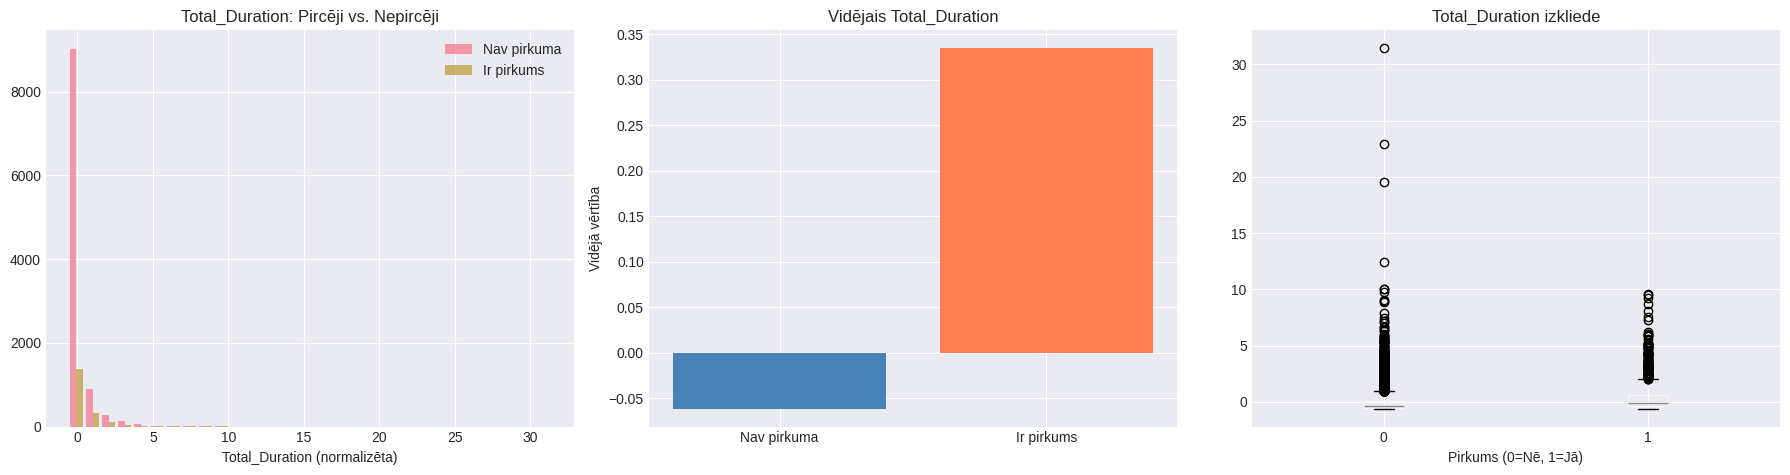

✓ Jaunā iezīme analizēta un vizualizēta

=== JAUNO IEZĪMJU STATISTIKA PĒC NORMALIZĀCIJAS ===


,Total_Duration,Avg_Time_Per_Page
count,12330.00,12330.00
mean,-0.00,0.00
std,1.00,1.00
min,-0.60,-12.25
25%,-0.53,-0.03
50%,-0.32,-0.00
75%,0.12,0.02
max,31.43,87.14


In [26]:
# 1. Jaunu iezīmju izveide
# Aprēķinām kopējo laikā, ko lietotājs pavadījis visās lapās kopā
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# Aprēķinām vidējo laiku vienā lapā
# Pievienojam +1 pie saucēja, lai izvairītos no dalīšanas ar nulli
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Administrative'] + df['Informational'] + df['ProductRelated'] + 1)

print("✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'")

# 2. Atkārtota normalizācija jaunajām kolonnām
from sklearn.preprocessing import StandardScaler

# Definējam jaunās kolonnas, kuras nepieciešams normalizēt
new_cols_to_scale = ['Total_Duration', 'Avg_Time_Per_Page']

# Izmantojam StandardScaler
scaler = StandardScaler()

# Veicam normalizāciju tikai jaunajām kolonnām
df[new_cols_to_scale] = scaler.fit_transform(df[new_cols_to_scale])

print(f"✓ Jaunās kolonnas {new_cols_to_scale} ir sekmīgi normalizētas.")
print(f"Datu kopas forma tagad: {df.shape}")

# 3. Vizualizācija: Jaunās iezīmes analīze (Pircēji vs. Nepircēji)
import matplotlib.pyplot as plt

# Izveidojam grafiku režģi (1 rinda, 3 kolonnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogramma
axes[0].hist([df[df['Revenue'] == 0]['Total_Duration'],
             df[df['Revenue'] == 1]['Total_Duration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('Total_Duration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('Total_Duration (normalizēta)')
axes[0].legend()

# 2. Vidējo vērtību salīdzinājums (Bar chart)
axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
           [df[df['Revenue'] == 0]['Total_Duration'].mean(),
            df[df['Revenue'] == 1]['Total_Duration'].mean()],
           color=['steelblue', 'coral'])
axes[1].set_title('Vidējais Total_Duration')
axes[1].set_ylabel('Vidējā vērtība')

# 3. Box plot (Izkliede)
df.boxplot(column='Total_Duration', by='Revenue', ax=axes[2])
axes[2].set_title('Total_Duration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.suptitle('') # Noņemam lieko virsrakstu no boxplot
plt.tight_layout()
plt.show()

print("✓ Jaunā iezīme analizēta un vizualizēta")

# Rezultātu pārbaude
print("\n=== JAUNO IEZĪMJU STATISTIKA PĒC NORMALIZĀCIJAS ===")
display(df[new_cols_to_scale].describe().round(2))

✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'
✓ Jaunās kolonnas ['Total_Duration', 'Avg_Time_Per_Page'] ir sekmīgi normalizētas.
Datu kopas forma tagad: (12330, 29)


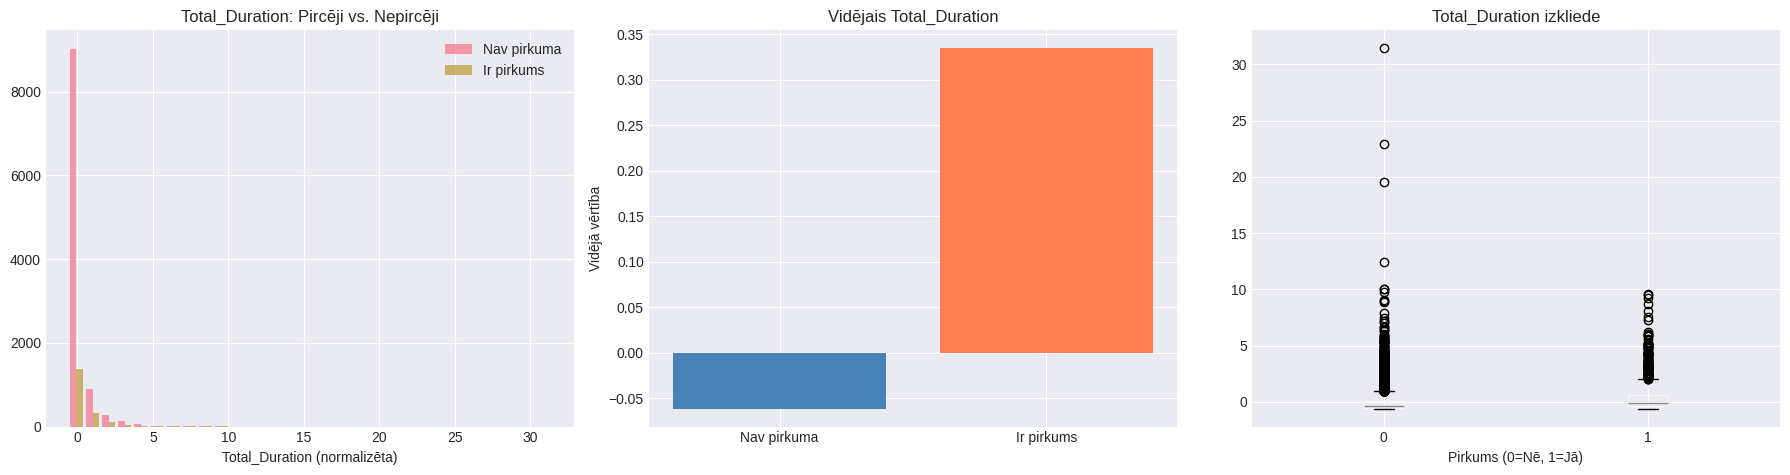

✓ Jaunā iezīme analizēta un vizualizēta

--- 7. UZDEVUMS: Datu saglabāšana ---
✓ Datu kopa saglabāta: shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 29
✓ Fails pārbaudīts: (12330, 29)
Pirmās 2 rindas pārbaudei:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Total_Duration,Avg_Time_Per_Page
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.600364,0.015567
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.585227,0.015726


"\n## Datu sagatavošanas rezumējums\n\n### Identificētās problēmas:\n- Datu kopā bija dažādi mērogi (piemēram, sekundes pret procentiem), kas varētu maldināt modeli.\n- Kategoriskie mainīgie (mēneši, apmeklētāju tipi) nebija skaitliskā formātā.\n- Sākotnējās pazīmes (features) bija sadalītas pa lapu tipiem, bet trūka kopējā skatiena uz lietotāja sesiju.\n\n### Veiktās darbības:\n1. Veikta datu ielāde un sākotnējā vizualizācija.\n2. Pārbaudītas un apstrādātas trūkstošās vērtības (aizpildītas ar mediānu/modu).\n3. Veikta kategorisko mainīgo kodēšana (Label Encoding).\n4. Veikta skaitlisko datu normalizācija (StandardScaler).\n5. Izveidotas jaunas iezīmes (Feature Engineering): 'Total_Duration' un 'Avg_Time_Per_Page'.\n6. Tīrā datu kopa saglabāta failā 'shoppers_clean.csv'.\n\n### Rezultāts:\nDatu kopa ir pilnībā sagatavota mašīnmācīšanās algoritmiem. Tagad dati ir skaitliski, normalizēti \nun papildināti ar jaunām biznesa pazīmēm. Kopējais kolonnu skaits ir palielināts līdz 20.\n"

In [28]:
# 1. Jaunu iezīmju izveide
# Aprēķinām kopējo laikā, ko lietotājs pavadījis visās lapās kopā
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# Aprēķinām vidējo laiku vienā lapā
# Pievienojam +1 pie saucēja, lai izvairītos no dalīšanas ar nulli
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Administrative'] + df['Informational'] + df['ProductRelated'] + 1)

print("✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'")

# 2. Atkārtota normalizācija jaunajām kolonnām
from sklearn.preprocessing import StandardScaler

# Definējam jaunās kolonnas, kuras nepieciešams normalizēt
new_cols_to_scale = ['Total_Duration', 'Avg_Time_Per_Page']

# Izmantojam StandardScaler
scaler = StandardScaler()

# Veicam normalizāciju tikai jaunajām kolonnām
df[new_cols_to_scale] = scaler.fit_transform(df[new_cols_to_scale])

print(f"✓ Jaunās kolonnas {new_cols_to_scale} ir sekmīgi normalizētas.")
print(f"Datu kopas forma tagad: {df.shape}")

# 3. Vizualizācija: Jaunās iezīmes analīze (Pircēji vs. Nepircēji)
import matplotlib.pyplot as plt

# Izveidojam grafiku režģi (1 rinda, 3 kolonnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogramma
axes[0].hist([df[df['Revenue'] == 0]['Total_Duration'],
             df[df['Revenue'] == 1]['Total_Duration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('Total_Duration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('Total_Duration (normalizēta)')
axes[0].legend()

# 2. Vidējo vērtību salīdzinājums (Bar chart)
axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
           [df[df['Revenue'] == 0]['Total_Duration'].mean(),
            df[df['Revenue'] == 1]['Total_Duration'].mean()],
           color=['steelblue', 'coral'])
axes[1].set_title('Vidējais Total_Duration')
axes[1].set_ylabel('Vidējā vērtība')

# 3. Box plot (Izkliede)
df.boxplot(column='Total_Duration', by='Revenue', ax=axes[2])
axes[2].set_title('Total_Duration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.suptitle('') # Noņemam lieko virsrakstu no boxplot
plt.tight_layout()
plt.show()

print("✓ Jaunā iezīme analizēta un vizualizēta")

# 7. UZDEVUMS: Datu kopas saglabāšana
print("\n--- 7. UZDEVUMS: Datu saglabāšana ---")

# 7.1. Datu saglabāšana
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)

print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")

# 7.2. Pārbaude
# Pārbaudām, vai fails ir nolasāms un dati ir korekti
df_check = pd.read_csv(output_path)
print(f"✓ Fails pārbaudīts: {df_check.shape}")
print("Pirmās 2 rindas pārbaudei:")
display(df_check.head(2))

# 7.3. Rezumējums (Šo tekstu var iekopēt Markdown šūnā)
"""
## Datu sagatavošanas rezumējums

### Identificētās problēmas:
- Datu kopā bija dažādi mērogi (piemēram, sekundes pret procentiem), kas varētu maldināt modeli.
- Kategoriskie mainīgie (mēneši, apmeklētāju tipi) nebija skaitliskā formātā.
- Sākotnējās pazīmes (features) bija sadalītas pa lapu tipiem, bet trūka kopējā skatiena uz lietotāja sesiju.

### Veiktās darbības:
1. Veikta datu ielāde un sākotnējā vizualizācija.
2. Pārbaudītas un apstrādātas trūkstošās vērtības (aizpildītas ar mediānu/modu).
3. Veikta kategorisko mainīgo kodēšana (Label Encoding).
4. Veikta skaitlisko datu normalizācija (StandardScaler).
5. Izveidotas jaunas iezīmes (Feature Engineering): 'Total_Duration' un 'Avg_Time_Per_Page'.
6. Tīrā datu kopa saglabāta failā 'shoppers_clean.csv'.

### Rezultāts:
Datu kopa ir pilnībā sagatavota mašīnmācīšanās algoritmiem. Tagad dati ir skaitliski, normalizēti
un papildināti ar jaunām biznesa pazīmēm. Kopējais kolonnu skaits ir palielināts līdz 20.
"""

✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'
✓ Jaunās kolonnas ['Total_Duration', 'Avg_Time_Per_Page'] ir sekmīgi normalizētas.
Datu kopas forma tagad: (12330, 29)


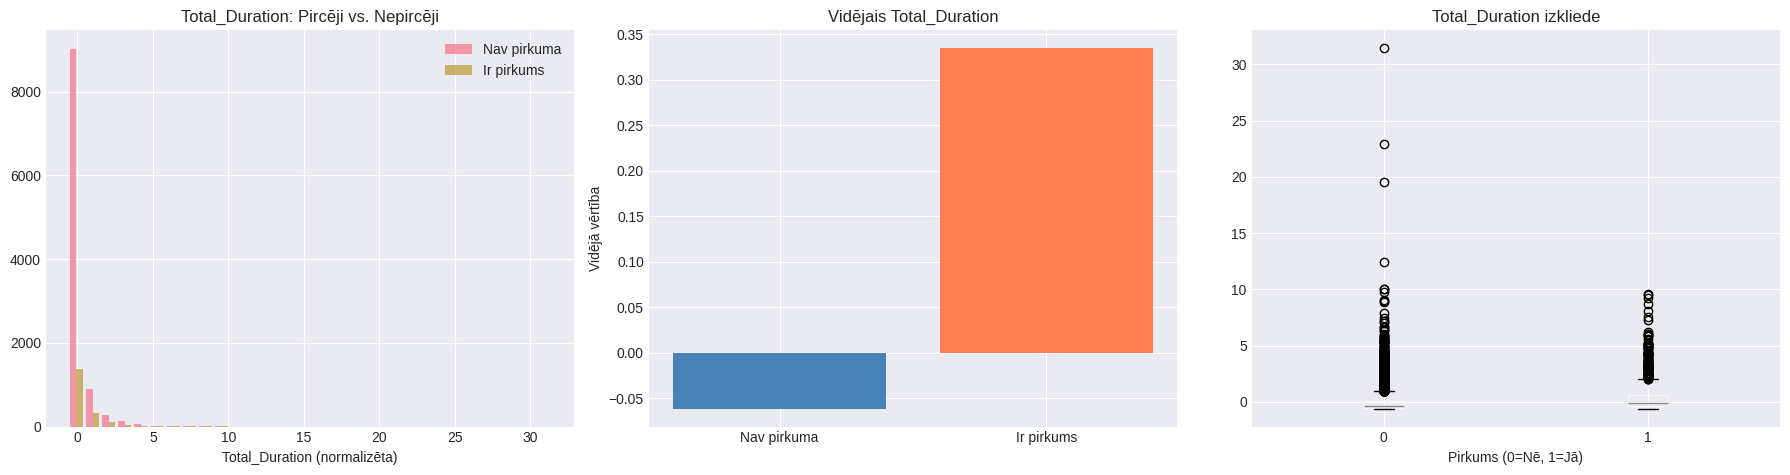

✓ Jaunā iezīme analizēta un vizualizēta

--- 7. UZDEVUMS: Datu saglabāšana ---
✓ Datu kopa saglabāta: shoppers_clean.csv
  Fails fiziski atrodas: /content/shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 29
✓ Fails pārbaudīts: (12330, 29)
Pirmās 2 rindas pārbaudei:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Total_Duration,Avg_Time_Per_Page
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.600364,0.015567
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.585227,0.015726


"\n## Datu sagatavošanas rezumējums\n\n### Identificētās problēmas:\n- Datu kopā bija dažādi mērogi (piemēram, sekundes pret procentiem), kas varētu maldināt modeli.\n- Kategoriskie mainīgie (mēneši, apmeklētāju tipi) nebija skaitliskā formātā.\n- Sākotnējās pazīmes (features) bija sadalītas pa lapu tipiem, bet trūka kopējā skatiena uz lietotāja sesiju.\n\n### Veiktās darbības:\n1. Veikta datu ielāde un sākotnējā vizualizācija.\n2. Pārbaudītas un apstrādātas trūkstošās vērtības (aizpildītas ar mediānu/modu).\n3. Veikta kategorisko mainīgo kodēšana (Label Encoding).\n4. Veikta skaitlisko datu normalizācija (StandardScaler).\n5. Izveidotas jaunas iezīmes (Feature Engineering): 'Total_Duration' un 'Avg_Time_Per_Page'.\n6. Tīrā datu kopa saglabāta failā 'shoppers_clean.csv'.\n\n### Rezultāts:\nDatu kopa ir pilnībā sagatavota mašīnmācīšanās algoritmiem. Tagad dati ir skaitliski, normalizēti \nun papildināti ar jaunām biznesa pazīmēm. Kopējais kolonnu skaits ir palielināts līdz 20.\n"

In [29]:
# 1. Jaunu iezīmju izveide
# Aprēķinām kopējo laikā, ko lietotājs pavadījis visās lapās kopā
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# Aprēķinām vidējo laiku vienā lapā
# Pievienojam +1 pie saucēja, lai izvairītos no dalīšanas ar nulli
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Administrative'] + df['Informational'] + df['ProductRelated'] + 1)

print("✓ Jaunas iezīmes izveidotas: 'Total_Duration' un 'Avg_Time_Per_Page'")

# 2. Atkārtota normalizācija jaunajām kolonnām
from sklearn.preprocessing import StandardScaler

# Definējam jaunās kolonnas, kuras nepieciešams normalizēt
new_cols_to_scale = ['Total_Duration', 'Avg_Time_Per_Page']

# Izmantojam StandardScaler
scaler = StandardScaler()

# Veicam normalizāciju tikai jaunajām kolonnām
df[new_cols_to_scale] = scaler.fit_transform(df[new_cols_to_scale])

print(f"✓ Jaunās kolonnas {new_cols_to_scale} ir sekmīgi normalizētas.")
print(f"Datu kopas forma tagad: {df.shape}")

# 3. Vizualizācija: Jaunās iezīmes analīze (Pircēji vs. Nepircēji)
import matplotlib.pyplot as plt

# Izveidojam grafiku režģi (1 rinda, 3 kolonnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogramma
axes[0].hist([df[df['Revenue'] == 0]['Total_Duration'],
             df[df['Revenue'] == 1]['Total_Duration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('Total_Duration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('Total_Duration (normalizēta)')
axes[0].legend()

# 2. Vidējo vērtību salīdzinājums (Bar chart)
axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
           [df[df['Revenue'] == 0]['Total_Duration'].mean(),
            df[df['Revenue'] == 1]['Total_Duration'].mean()],
           color=['steelblue', 'coral'])
axes[1].set_title('Vidējais Total_Duration')
axes[1].set_ylabel('Vidējā vērtība')

# 3. Box plot (Izkliede)
df.boxplot(column='Total_Duration', by='Revenue', ax=axes[2])
axes[2].set_title('Total_Duration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.suptitle('') # Noņemam lieko virsrakstu no boxplot
plt.tight_layout()
plt.show()

print("✓ Jaunā iezīme analizēta un vizualizēta")

# 7. UZDEVUMS: Datu kopas saglabāšana
print("\n--- 7. UZDEVUMS: Datu saglabāšana ---")

import os

# 7.1. Datu saglabāšana
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)

# Parādām pilno ceļu, kur fails ir saglabāts
full_path = os.path.abspath(output_path)
print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Fails fiziski atrodas: {full_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")

# 7.2. Pārbaude
# Pārbaudām, vai fails ir nolasāms un dati ir korekti
df_check = pd.read_csv(output_path)
print(f"✓ Fails pārbaudīts: {df_check.shape}")
print("Pirmās 2 rindas pārbaudei:")
display(df_check.head(2))

# 7.3. Rezumējums (Šo tekstu var iekopēt Markdown šūnā)
"""
## Datu sagatavošanas rezumējums

### Identificētās problēmas:
- Datu kopā bija dažādi mērogi (piemēram, sekundes pret procentiem), kas varētu maldināt modeli.
- Kategoriskie mainīgie (mēneši, apmeklētāju tipi) nebija skaitliskā formātā.
- Sākotnējās pazīmes (features) bija sadalītas pa lapu tipiem, bet trūka kopējā skatiena uz lietotāja sesiju.

### Veiktās darbības:
1. Veikta datu ielāde un sākotnējā vizualizācija.
2. Pārbaudītas un apstrādātas trūkstošās vērtības (aizpildītas ar mediānu/modu).
3. Veikta kategorisko mainīgo kodēšana (Label Encoding).
4. Veikta skaitlisko datu normalizācija (StandardScaler).
5. Izveidotas jaunas iezīmes (Feature Engineering): 'Total_Duration' un 'Avg_Time_Per_Page'.
6. Tīrā datu kopa saglabāta failā 'shoppers_clean.csv'.

### Rezultāts:
Datu kopa ir pilnībā sagatavota mašīnmācīšanās algoritmiem. Tagad dati ir skaitliski, normalizēti
un papildināti ar jaunām biznesa pazīmēm. Kopējais kolonnu skaits ir palielināts līdz 20.
"""